In [6]:
# 20240826 处理数据，用于生成异常图，用于辅助预训练

# 生成预训练数据信息  

import os

root = '/home/data/Datasets/public/collection_of_images/pretrain_2406/'
base_file = root + 'metal_images_for_pretrain_v3_pretrain_mini.txt'

'''
# 去除训练数据，防止信息泄露
home = '/home/data/Datasets/public/'
dirs = ['pipeData', 'casting_billet', 'steel_rail']
train_dir_dict = {}
for dr in dirs:
    if dr == 'steel_rail':
        train_val_path = home + dr + '/train_data_06/train_val.txt'
    else:
        train_val_path = home + dr + '/train_val.txt'
    
    train_dir_dict[dr] = []
    with open(train_val_path, 'r') as r_data:
        for line in r_data:
            data = line.strip()
            if len(data) < 1:
                continue
            name = data.split('/')[-1]
            if dr == 'steel_rail':
                if 'normal_images' in name or "unknown_images" in name or "unlabeled" in name:
                    name = name.split('.')[0].replace('_', '/').replace('normal/images', 'normal_images').replace('unknown/images', 'unknown_images')
                    print(name)
                else:
                    continue
            elif dr == 'pipeData':
                if '(' in name:
                    name = name.split('(')[0]
            train_dir_dict[dr].append(name)

print('train_dir_dict ', len(train_dir_dict))
'''

cnt = 0
all_cnt = 0
all_path = set()
save_file = base_file + '.skip'
with open(base_file, 'r', encoding='utf-8') as r_data, open(save_file, 'w') as w_save:
    for line in r_data:
        data = line.strip().split(' ')
        if len(data) < 2:
            print('error! ', data)
            continue
        all_cnt += 1
        path = data[0].strip()
        if 'Cast_Iron_Pip' in path or 'PCBData' in path:
            continue
        '''
        flag = False
        for dr in dirs:
            if dr in path:
                for name in train_dir_dict[dr]:
                    if name in path:
                        print('skip path ', path, ' name ', name)
                        flag = True
                        break
                if flag:
                    break
        if flag:
            cnt += 1
            continue
        '''
        w_save.write(line)
        
        if not os.path.exists(path):
            print(path)
            cnt += 1
        all_path.add(path)
print('miss cnt ', cnt, ' / ', all_cnt, ' --> ', len(all_path))


names_txt = root + 'metal_images_for_pretrain_v3_names.txt'
with open(names_txt, 'r') as r_data:
    for line in r_data:
        data = line.strip()
        if len(data) < 1:
            continue
        names = eval(data)
print('names ', len(names))

manual_categories = root + '../categories.txt'
import pandas as pd
# 读取CSV文件
source_dataset = {}
with open(manual_categories, 'r', encoding='utf-8') as r_data:
    for line in r_data:
        data = line.strip().split('\t')
        if len(data) < 2:
            continue
        ori_name = data[0].strip()
        name_trans = data[1].strip()
        dataset = data[3].strip()
        material = data[4].strip()
        if len(name_trans) > 1:
            name = name_trans
        else:
            name = ori_name
        if name in names:
            source_dataset[name] = {'dataset':dataset, 'material':material, 'path':[]}
print('source_dataset ', len(source_dataset))

data2info = {}
all_txt = root + '../all_images_for_pretrain_ori_clean.csv'
cnt = 0
with open(all_txt, 'r', encoding='utf-8') as r_data:
    for line in r_data:
        data = line.strip().split(',')
        path = data[0].strip()
        source = data[1].strip()
        if source not in source_dataset:
            continue
        if path not in all_path:
            #print('no such path ', path)
            continue
        cnt += 1
        if cnt % 10000 == 0:
            print('cnt ', cnt)
        label = data[2].strip()
        if label == 'good':
            source_dataset[source]['path'].append(path)
        
        mask = data[3].strip()
        if len(mask) > 3 and (not os.path.exists(mask)):
            print('no such mask ', mask)
            #continue
            mask = ''
        
        
        data2info[data[0]] = {'source':source, 'label':label, 'mask':mask}
print('data2info ', len(data2info),  ' source_dataset ', len(source_dataset), ' all_path ', len(all_path))

cnt = 0
for item in all_path:
    if item not in data2info:
        print(item)
        cnt += 1
print('miss ', cnt)

import random
save_file_info = base_file + '.info'   # metal_images_for_pretrain_v3_pretrain_mini.txt.info
save_file_name = names_txt + '.info'   # metal_images_for_pretrain_v3_names.txt.info
with open(save_file_info, 'w') as w_info, open(save_file_name, 'w') as w_name:
    for item in data2info:
        info = data2info[item]
        w_info.write(item+'\t'+info['source']+'\t'+info['label']+'\t'+info['mask']+'\n')
    print('save info done!')
    for item in source_dataset:
        info = source_dataset[item]
        select_path = random.sample(info["path"], min(len(info["path"]), 5))
        w_name.write(item+'\t'+info['dataset']+'\t'+info['material']+'\t'+','.join(select_path)+'\n')
    print('save names done!')





miss cnt  0  /  130172  -->  128672
names  64
source_dataset  64
cnt  10000
cnt  20000
cnt  30000
cnt  40000
cnt  50000
cnt  60000
cnt  70000
cnt  80000
cnt  90000
cnt  100000
cnt  110000
cnt  120000
data2info  128672  source_dataset  64  all_path  128672
miss  0
save info done!
save names done!


In [13]:
# 2024 0905  
# 检查预训练数据
# 增加相对明确定义
# 在winclip上测试，增加明确定义是否有利于提升异常检测效果？
# 生成之后，改写预训练代码，预训练，尝试效果

root = '/home/data/liuchuni/projects/fsad_big_model/defect_lvlms/dataset/'   # move from /home/data/Datasets/public/collection_of_images/pretrain_2406
# 数据文本描述+正常样本sample
data_des_txt = root + 'datasets_des_info.txt'
pretrain_data = root + 'metal_images_for_pretrain_v3_pretrain_mini.txt.info'

# check all image path is available
cnt = 0
error_cnt = 0
with open(pretrain_data, 'r') as r_data:
    for line in r_data:
        data = line.strip().split('\t')
        if len(data) < 3:
            error_cnt += 1
            print(data)
            continue
        path = data[0].strip()
        if not os.path.exists(path):
            error_cnt += 1
            print('not eixst! ', path)
            continue
        cnt += 1
print('cnt : ', cnt, ' error_cnt ', error_cnt)


# read dataset text description and normal samples, form a function

import re
import json

def get_class_mapping(text):
    # 使用正则表达式提取 "photo of" 和 "for anomaly detection" 之间的文字
    pattern = r"photo of (.*?) for anomaly detection"
    match = re.search(pattern, text)
    extracted_text = 'textured surface'
    if match:
        extracted_text = match.group(1)
        #print("提取的文字:", extracted_text)
    #else:
    #    print("未找到指定文字。默认为 textured surface")
    return extracted_text

def get_cate_descriptions_and_samples(des_path, save_path):
    """
    des_path: cate_name \t dataset \t describe_path \t samples
    """
    cate2data = {}
    with open(des_path, 'r', encoding='utf-8') as r_data, open(save_path, 'w') as w_json:
        for line in r_data:
            data = line.split('\t')
            if len(data)< 4:
                print('length < 4 ', data)
                continue
            cate_name = data[0].strip()
            _ = data[1].strip()  # dataset
            des_txt = data[2].strip()
            cate2data[cate_name] = {}
            cate2data[cate_name]['des'] = {'good':[], 'defect':[]}
            print('handle ', cate_name)
            # decode the defect description
            good_sentence = ''
            defect_sentence = ''
            defect2des = {}
            with open(des_txt, 'r', encoding='utf-8') as r_des:
                for rs_line in r_des:
                    des_data = rs_line.strip()
                    if len(des_data) < 2:
                        continue
                    if len(good_sentence) < 1:
                        good_sentence = des_data
                    elif len(defect_sentence) < 1:
                        defect_sentence = des_data
                    else:
                        defect_cate, defect_des = des_data.split(':')
                        defect2des[defect_cate] = defect_des
            # 解析类别映射
            cate2data[cate_name]['map'] = get_class_mapping(good_sentence)
            good_sentence = good_sentence.split('anomaly detection,')[-1].strip()
            # 解析state_normal_list
            words = good_sentence.split('should be without any')[-1].replace(' or ', ',').replace(' ', '').replace(',,', ',').replace('.', '').strip()
            prefix = '{} '+good_sentence.split('should be without any')[0].strip()+' should be without any '
            for item in words.split(','):
                if len(item) > 1:
                    cate2data[cate_name]['des']['good'].append(prefix+item)
            # 解析 state_anomaly_list
            if len(defect2des) < 1:
                anomaly_des = '{} '+defect_sentence.split('anomaly detection,')[-1].strip()
                if anomaly_des.endswith('.'):
                    anomaly_des = anomaly_des[:-1]
                cate2data[cate_name]['des']['defect'].append(anomaly_des)
            else:
                for defect_cate in defect2des:
                    defect_des = defect2des[defect_cate].lower()
                    if defect_des.endswith('.'):
                        defect_des = defect_des[:-1]
                    anomaly_des = '{} with '+defect_cate.lower()+' defect, it appears as '+defect_des
                    cate2data[cate_name]['des']['defect'].append(anomaly_des)

            samples = data[3].strip().split(',')
            for smp in samples:
                if not os.path.exists(smp):
                    print('no such sample !!!!!! ', smp)
                    continue
            cate2data[cate_name]['samples'] = samples

        cate2data_str = json.dumps(cate2data, indent=4)
        w_json.write(cate2data_str)
    print('get_cate_descriptions_and_samples done')


des_path = root + 'datasets_des_info.txt'
save_path = root + 'datasets_des_info.json'
get_cate_descriptions_and_samples(des_path, save_path)




cnt :  128697  error_cnt  0
names  64
handle  AITEX
handle  BSD_cls
handle  BSData
handle  BTech_02
handle  Blotchy
handle  DAGM2007_Class1
handle  DAGM2007_Class10
handle  DAGM2007_Class2
handle  DAGM2007_Class3
handle  DAGM2007_Class4
handle  DAGM2007_Class5
handle  DAGM2007_Class6
handle  DAGM2007_Class7
handle  DAGM2007_Class8
handle  DAGM2007_Class9
handle  Fibrous
handle  KolektorSDD
handle  KolektorSDD2
handle  Magnetic_tile
handle  Marbled
handle  Matted
handle  Mesh
handle  Perforated
handle  Stratified
handle  Woven_001
handle  Woven_068
handle  Woven_104
handle  Woven_125
handle  Woven_127
handle  aluminum
handle  aluminum_ingot
handle  aluminum_strip
handle  cold_rolled_strip_steel
handle  gc10_steel_plate
handle  grid
handle  hot_rolled_strip_steel
handle  leather
handle  medium_heavy_plate
handle  metal_plate
handle  moderately_thick_plates
handle  neu_aluminum
handle  neu_hot_rolled_strip
handle  neu_leather
handle  neu_magnetic_tiles
handle  neu_rail
handle  neu_steel
h

In [12]:
import json


save_path = '/home/data/liuchuni/projects/fsad_big_model/defect_lvlms/dataset/datasets_des_info.json'

with open(save_path) as f:
     result=json.load(f)

print(len(result))
print('result ', result['casting_billet'])

62
result  {'des': {'good': ['{} with a smooth, uniform finish, which should be without any damage', '{} with a smooth, uniform finish, which should be without any flaw', '{} with a smooth, uniform finish, which should be without any defect', '{} with a smooth, uniform finish, which should be without any faults', '{} with a smooth, uniform finish, which should be without any cracks', '{} with a smooth, uniform finish, which should be without any pits', '{} with a smooth, uniform finish, which should be without any irregularities', '{} with a smooth, uniform finish, which should be without any contamination', '{} with a smooth, uniform finish, which should be without any inclusions', '{} with a smooth, uniform finish, which should be without any improperfusion'], 'defect': ['{} with cutting opening defect, it appears as  dark rectangle that basically runs across the entire image, with irregular jagged edges, some with material accumulation, and a rough surface, indicating that the cutti

image  254  --  0
image  254  --  0
anomaly_map  (27, 27)
anomaly_map max  1.0882862  -- min  0.17883201
anomaly_map_t_fn max  tensor(0.0688)  -- min  tensor(0.0113)
softmax_activation_map max  tensor(0.0023)  -- min  tensor(0.0009)
anomaly_map2  (27, 27)
anomaly_map2 max  1.0711178  -- min  0.25581652
anomaly_map2_t_fn max  tensor(0.0598)  -- min  tensor(0.0143)
softmax_activation_map2 max  tensor(0.0021)  -- min  tensor(0.0009)
anomaly_map3  (27, 27)
anomaly_map3 max  0.9070505  -- min  0.29215473
anomaly_map_t_f3n max  tensor(0.0502)  -- min  tensor(0.0162)
softmax_activation_map3 max  tensor(0.0018)  -- min  tensor(0.0009)
loss 1  tensor(7.7308e-05)
loss 3  tensor(6.0637e-05)
l2 loss 1  tensor(0.)
l2 loss 3  tensor(0.1216)
cosine_sim_1  tensor([1.])  cosine_sim_2  tensor([0.9257])  cosine_sim_3  tensor([0.9392])


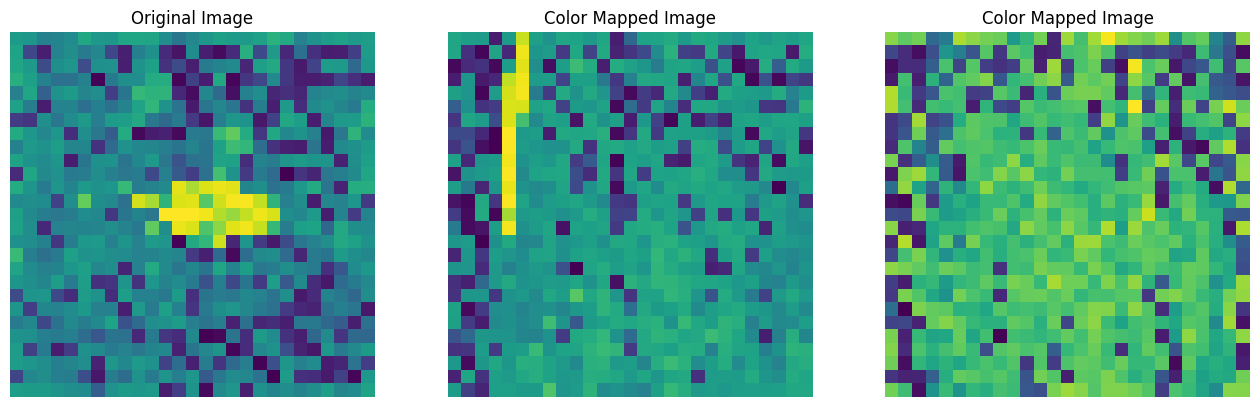

img_resized max  0.87603885  -- min  0.42698574
[[3.9121482]]
img_resized_filter max  0.22392783  -- min  0.10914355
anomaly_map_final  (224, 224)   1.0856329   0.1919603


/tmp/ipykernel_50913/1059705122.py:111: DeprecationWarning: BILINEAR is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BILINEAR instead.
  img_resized = np.array(Image.fromarray(anomaly_map).resize((7, 7), Image.BILINEAR))


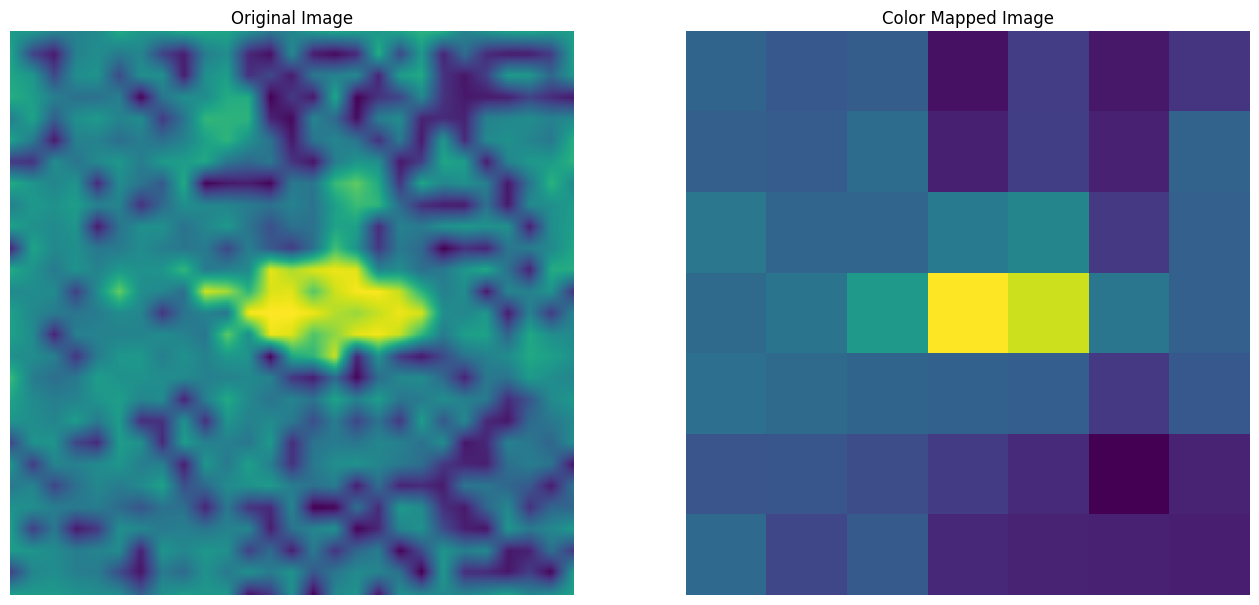

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import cv2
from PIL import Image

# 读取或生成一个图像（假设是灰度图像）
# 示例：生成一个具有不同值的灰度图像
image = np.random.randint(0, 255, (100, 100), dtype=np.uint8)
print('image ', np.max(image), ' -- ', np.min(image))
# 固定最大值
fixed_max_val = 50

## 归一化图像到 [0, fixed_max_val] 范围
#normalized_image = cv2.normalize(image, None, 0, fixed_max_val, cv2.NORM_MINMAX)
# 归一化到 [0, 255] 范围以应用颜色映射
normalized_image_255 = (image ).astype(np.uint8)  # cv2.normalize(normalized_image, None, 0, 255, cv2.NORM_MINMAX)
print('image ', np.max(normalized_image_255), ' -- ', np.min(normalized_image_255))

# 应用颜色映射
color_mapped_image = cv2.applyColorMap(np.uint8(normalized_image_255), cv2.COLORMAP_JET)

#with open('/home/data/Datasets/public/tmp_features/home/data/Datasets/public/own_anomaly_detect/casting_billet/test/cutting_open/Co_210_anomaly.npy', 'rb') as f:
#with open('/home/data/Datasets/public/tmp_features/own_anomaly_detect/casting_billet/test/good/Ba_284_anomaly.npy', 'rb') as f:
#with open('/home/data/Datasets/public/tmp_features/own_anomaly_detect/casting_billet/test/longitudinal_cracks/Lc_166_anomaly.npy', 'rb') as f:
#with open('/home/data/Datasets/public/tmp_features_radio/pipeData/images_all/106060578_anomaly.npy', 'rb') as f:
with open('/home/data/Datasets/public/tmp_features_huge/medium_heavy_plate/RM/RM_341_anomaly.npy', 'rb') as f:
    anomaly_map = np.load(f)
print('anomaly_map ', anomaly_map.shape)
print('anomaly_map max ', np.max(anomaly_map), ' -- min ', np.min(anomaly_map))
anomaly_map_t = torch.tensor(anomaly_map).unsqueeze(0)
anomaly_map_t_f = anomaly_map_t.view(1, -1)
anomaly_map_t_fn = anomaly_map_t_f / (anomaly_map_t_f).norm(2, dim=1, keepdim=True)
print('anomaly_map_t_fn max ', torch.max(anomaly_map_t_fn), ' -- min ', torch.min(anomaly_map_t_fn))
softmax_activation_map = F.softmax(anomaly_map_t_f, dim=1).view_as(anomaly_map_t)  # 重新变回原来的形状
print('softmax_activation_map max ', torch.max(softmax_activation_map), ' -- min ', torch.min(softmax_activation_map))

with open('/home/data/Datasets/public/tmp_features_huge/pipeData/images_all/106060578_anomaly.npy', 'rb') as f:
    anomaly_map2 = np.load(f)
print('anomaly_map2 ', anomaly_map2.shape)
print('anomaly_map2 max ', np.max(anomaly_map2), ' -- min ', np.min(anomaly_map2))
anomaly_map2_t = torch.tensor(anomaly_map2).unsqueeze(0)
anomaly_map2_t_f = anomaly_map2_t.view(1, -1)
anomaly_map2_t_fn = anomaly_map2_t_f / anomaly_map2_t_f.norm(2, dim=1, keepdim=True)
print('anomaly_map2_t_fn max ', torch.max(anomaly_map2_t_fn), ' -- min ', torch.min(anomaly_map2_t_fn))
softmax_activation_map2 = F.softmax(anomaly_map2_t_f, dim=1).view_as(anomaly_map2_t)  # 重新变回原来的形状
print('softmax_activation_map2 max ', torch.max(softmax_activation_map2), ' -- min ', torch.min(softmax_activation_map2))


#with open('/home/data/Datasets/public/tmp_features/own_anomaly_detect/casting_billet/test/longitudinal_cracks/Lc_166_anomaly.npy', 'rb') as f:
#with open('/home/data/Datasets/public/tmp_features_radio/pipeData/images_all/106060578_anomaly.npy', 'rb') as f:
with open('/home/data/Datasets/public/tmp_features_huge/pipeData/images_all/99408937_anomaly.npy', 'rb') as f:
    anomaly_map3 = np.load(f)
print('anomaly_map3 ', anomaly_map3.shape)
print('anomaly_map3 max ', np.max(anomaly_map3), ' -- min ', np.min(anomaly_map3))
anomaly_map_t3 = torch.tensor(anomaly_map3).unsqueeze(0)
anomaly_map_t_f3 = anomaly_map_t3.view(1, -1)
anomaly_map_t_f3n = anomaly_map_t_f3 / anomaly_map_t_f3.norm(2, dim=1, keepdim=True)
print('anomaly_map_t_f3n max ', torch.max(anomaly_map_t_f3n), ' -- min ', torch.min(anomaly_map_t_f3n))
softmax_activation_map3 = F.softmax(anomaly_map_t_f3, dim=1).view_as(anomaly_map_t3)  # 重新变回原来的形状
print('softmax_activation_map3 max ', torch.max(softmax_activation_map3), ' -- min ', torch.min(softmax_activation_map3))

# 计算 Softmax 后的 MSE 损失
loss_fn = torch.nn.MSELoss(reduction='sum')
loss = loss_fn(softmax_activation_map, softmax_activation_map2)
print('loss 1 ', loss)
loss = loss_fn(softmax_activation_map, softmax_activation_map3)
print('loss 3 ', loss)

# use this one l2_loss with l2_norm
loss = torch.sum(torch.pow(torch.sub(anomaly_map_t_fn, anomaly_map_t_fn), 2))
print('l2 loss 1 ', loss)

loss = torch.sum(torch.pow(torch.sub(anomaly_map_t_fn, anomaly_map_t_f3n), 2))
print('l2 loss 3 ', loss)

cosine_sim_1 = F.cosine_similarity(anomaly_map_t_f, anomaly_map_t_f, dim=1)
cosine_sim_2 = F.cosine_similarity(anomaly_map_t_f, anomaly_map2_t_f, dim=1)
cosine_sim_3 = F.cosine_similarity(anomaly_map_t_f, anomaly_map_t_f3, dim=1)
print('cosine_sim_1 ', cosine_sim_1, ' cosine_sim_2 ', cosine_sim_2, ' cosine_sim_3 ', cosine_sim_3)


# 使用 matplotlib 展示结果
plt.figure(figsize=(16, 16))

# 显示原始图像
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(anomaly_map)
plt.axis('off')

# 显示颜色映射后的图像
plt.subplot(1, 3, 2)
plt.title('Color Mapped Image')
plt.imshow(anomaly_map2)
plt.axis('off')

# 显示颜色映射后的图像
plt.subplot(1, 3, 3)
plt.title('Color Mapped Image')
plt.imshow(anomaly_map3)
plt.axis('off')

plt.show()


import cv2
#img_resized = cv2.resize(anomaly_map, (224, 224), interpolation=cv2.INTER_LINEAR)
img_resized = np.array(Image.fromarray(anomaly_map).resize((7, 7), Image.BILINEAR))

from scipy.ndimage import gaussian_filter
#img_resized_filter = gaussian_filter(img_resized,sigma=1)
print('img_resized max ', np.max(img_resized), ' -- min ', np.min(img_resized))


def l2_normalize(v):
    norm = np.linalg.norm(v, keepdims=True)  # 计算 L2 范数
    print(norm)
    if norm == 0:  # 防止除以零
        return v
    return v / norm  # 返回归一化后的向量

img_resized_filter = l2_normalize(img_resized)
print('img_resized_filter max ', np.max(img_resized_filter), ' -- min ', np.min(img_resized_filter))

anomaly_map_final = F.interpolate(torch.tensor(anomaly_map).unsqueeze(0).unsqueeze(0), size=224, mode='bilinear', align_corners=True)
anomaly_map_final = anomaly_map_final.squeeze().numpy()
print('anomaly_map_final ', anomaly_map_final.shape, ' ', anomaly_map_final.max(), ' ', anomaly_map_final.min())
anomaly_map_final = (anomaly_map_final - anomaly_map_final.min()) / np.ptp(anomaly_map_final)
# 使用 matplotlib 展示结果
plt.figure(figsize=(16, 16))

# 显示原始图像
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(anomaly_map_final)
plt.axis('off')

# 显示颜色映射后的图像
plt.subplot(1, 2, 2)
plt.title('Color Mapped Image')
plt.imshow(img_resized)
plt.axis('off')

plt.show()

In [32]:
# 生成待生成运行异常检测的meta.json
import os, json

root = '/home/data/liuchuni/projects/fsad_big_model/defect_lvlms/dataset/'
all_file = root + 'metal_images_for_pretrain_v3_pretrain_mini.txt.info'
save_file = root + 'metal_images_for_pretrain_v3_pretrain_mini.json'

all_cates = set()
meta_dict = {'train':{}, 'test':{}}
cnt = 0
with open(all_file, 'r', encoding='utf-8') as r_data, open(save_file, 'w', encoding='utf-8') as w_json:
    for line in r_data:
        data = line.strip().split('\t')
        if len(data) < 3:
            continue
        path = data[0].strip()
        if not os.path.exists(path):
            print('no such path ', path, ' !')
            continue
        cate = data[1].strip()
        label = data[2].strip()
        all_cates.add(cate)

        if cate not in meta_dict['test']:
            meta_dict['test'][cate] = []
        
        if label == 'good':
            anomaly = 0
            specie_name = 'good'
        else:
            anomaly = 1
            specie_name = 'defect'
        data_dict = {"img_path":path, "mask_path":'', "cls_name":cate, 'specie_name':specie_name, "anomaly":anomaly}
        meta_dict['test'][cate].append(data_dict)
        cnt += 1
        if cnt % 10000 == 0:
            print('cnt ... ', cnt)

    meta_dict_str = json.dumps(meta_dict, indent=4)
    w_json.write(meta_dict_str)
    print(list(all_cates))
    print('meta_dict ', len(meta_dict['test']))



cnt ...  10000
cnt ...  20000
cnt ...  30000
cnt ...  40000
cnt ...  50000
cnt ...  60000
cnt ...  70000
cnt ...  80000
cnt ...  90000
cnt ...  100000
cnt ...  110000
cnt ...  120000


['Marbled', 'Fibrous', 'metal_plate', 'neu_hot_rolled_strip', 'DAGM2007_Class10', 'KolektorSDD2', 'DAGM2007_Class9', 'neu_rail', 'tile', 'KolektorSDD', 'Blotchy', 'steel_rail', 'Magnetic_tile', 'medium_heavy_plate', 'cold_rolled_strip_steel', 'hot_rolled_strip_steel', 'AITEX', 'steel_pipe', 'Matted', 'Woven_068', 'leather', 'wood', 'Stratified', 'Woven_001', 'DAGM2007_Class5', 'neu_leather', 'road_crack', 'DAGM2007_Class4', 'tianchi_aluminum', 'DAGM2007_Class3', 'neu_aluminum', 'DAGM2007_Class2', 'BTech_02', 'hot_rolled_strip_annealing_picking', 'neu_tile', 'rail_surface', 'neu_steel', 'Woven_127', 'severstal_steel', 'Woven_125', 'aluminum_strip', 'DAGM2007_Class7', 'Mesh', 'ssgd_glasses', 'wukuang_medium_plate', 'DAGM2007_Class6', 'aluminum', 'neu_magnetic_tiles', 'moderately_thick_plates', 'Perforated', 'aluminum_ingot', 'bao_steel', 'BSD_cls', 'BSData', 'DAGM2007_Class8', 'gc10_steel_plate', 'grid', 'Woven_104', 'wide_thick_plate', 'nan_steel', 'DAGM2007_Class1']
meta_dict  61


In [ ]:
# 处理加上异常图的预训练数据集
import os, json
from PIL import Image
import numpy as np

root = '/home/data/Datasets/public/open_metal_datasets/'
all_file = root + 'metal_images_for_pretrain_v3_pretrain_mini.txt.info'
#save_file = root + 'metal_images_for_pretrain_v3_pretrain_mini_pretrain.txt'


def resize_anomaly_map(map_path, save_map_path, size):
    if not os.path.exists(map_path):
        print('map_path ', map_path, ' path ', path, '  not exists!')
        return 0
        
    anomaly_map = np.load(map_path)
    img_resized = np.array(Image.fromarray(anomaly_map).resize(size, Image.BILINEAR))
    # 保存缩放后的数据为.npy文件
    np.save(save_map_path, img_resized)
    return 1

all_cates = set()
cnt = 0
with open(all_file, 'r', encoding='utf-8') as r_data:  # , open(save_file, 'w', encoding='utf-8') as w_save:
    for line in r_data:
        data = line.strip().split('\t')
        if len(data) < 3:
            continue
        path = data[0].strip()
        if not os.path.exists(path):
            print('no such path ', path, ' !')
            continue
        cate = data[1].strip()
        label = data[2].strip()
        all_cates.add(cate)

        if 'steel_rail/unknown_images' in path:
            label = 'unknown'
        
        cate_ids = str(obj2id[cate])
        if 'defect' in label:
            label = 'defect'
        if label in obj2id:
            cate_ids += (','+str(obj2id[label]))

        
        # 缩放至原图大小
        with Image.open(path) as img:
            original_size = img.size  # 获取原图尺寸 (width, height)
            if len(original_size) == 3:
                print('original_size ', original_size)
                original_size = original_size[:2]
                
        #print('original_size ', original_size)

        map_path = path.replace('/home/data/Datasets/public/', '/home/data/Datasets/public/tmp_features_huge/')
        map_path = map_path[:-4]+'_anomaly.npy'

        if not os.path.exists(map_path):
            print(path)

        save_map_path = map_path.replace('_anomaly.npy', '_anomaly_resize.npy')
        if os.path.exists(save_map_path):
            os.remove(save_map_path)

        #resize_anomaly_map(map_path, save_map_path, original_size)
        #resize_anomaly_map(map_path.replace('/tmp_features_radio/', '/tmp_features_huge/'), save_map_path.replace('/tmp_features_radio/', '/tmp_features_huge/'))
        #resize_anomaly_map(map_path.replace('/tmp_features_radio/', '/tmp_features_base/'), save_map_path.replace('/tmp_features_radio/', '/tmp_features_base/'))
        

        #w_save.write(path+' '+cate_ids+' '+map_path+'\n')
        #if cate not in meta_dict['test']:
        #    meta_dict['test'][cate] = []
        
        #if label == 'good':
        #    anomaly = 0
        #    specie_name = 'good'
        #else:
        #    anomaly = 1
        #    specie_name = 'defect'
        #data_dict = {"img_path":path, "mask_path":'', "cls_name":cate, 'specie_name':specie_name, "anomaly":anomaly}
        #meta_dict['test'][cate].append(data_dict)
        cnt += 1
        if cnt % 10000 == 0:
            print('cnt ... ', cnt)


    print(list(all_cates))
    print(len(all_cates))



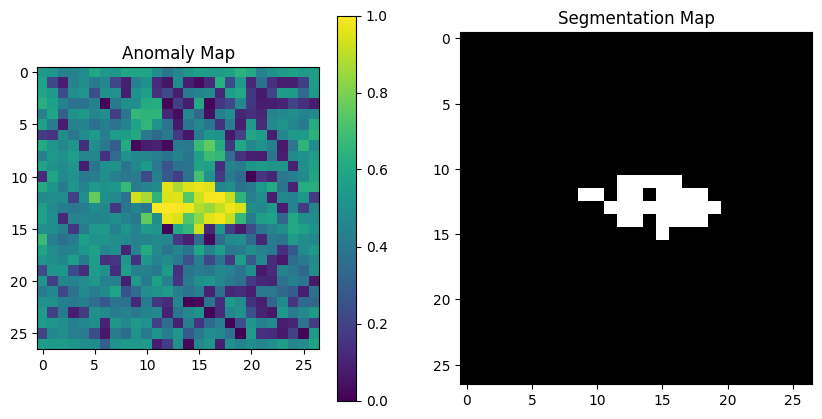

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def anomaly_map_to_segmentation(anomaly_map_path, output_image_path, threshold=0.5):
    """
    Convert an anomaly map in .npy format to a segmentation image.
    
    Parameters:
        anomaly_map_path (str): Path to the .npy anomaly map file.
        output_image_path (str): Path to save the resulting segmentation image.
        threshold (float): Threshold to binarize the anomaly map (default 0.5).
    """
    # Load the anomaly map
    anomaly_map = np.load(anomaly_map_path)
    
    # Normalize the anomaly map to [0, 1] range
    anomaly_map = (anomaly_map - np.min(anomaly_map)) / (np.max(anomaly_map) - np.min(anomaly_map))
    
    # Apply threshold to create segmentation mask
    segmentation_map = (anomaly_map > threshold).astype(np.uint8)  # Binary mask (0 or 1)
    
    # Save the segmentation mask as an image
    # Optionally convert 0/1 to 0/255 for visibility
    segmentation_image = (segmentation_map * 255).astype(np.uint8)
    segmentation_image = Image.fromarray(segmentation_image)
    #segmentation_image.save(output_image_path)
    
    # Display the results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Anomaly Map")
    plt.imshow(anomaly_map)
    plt.colorbar()
    
    plt.subplot(1, 2, 2)
    plt.title("Segmentation Map")
    plt.imshow(segmentation_map, cmap='gray')
    plt.show()

    # Ensure the segmentation is binary
    _, binary_map = cv2.threshold(segmentation_image, 127, 255, cv2.THRESH_BINARY)

    # Find contours (connected components)
    contours, _ = cv2.findContours(binary_map, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Prepare YOLO labels
    h, w = segmentation_image.shape
    yolo_labels = []

    for contour in contours:
        # Calculate the area of the contour
        area = cv2.contourArea(contour)
        if area < min_area:
            continue  # Skip small regions
        
        # Get bounding box for the contour
        x, y, box_w, box_h = cv2.boundingRect(contour)
        
        # Normalize bounding box to YOLO format
        x_center = (x + box_w / 2) / w
        y_center = (y + box_h / 2) / h
        norm_w = box_w / w
        norm_h = box_h / h

        yolo_labels.append((class_id, x_center, y_center, norm_w, norm_h))
    
    # Save YOLO labels to file
    with open(yolo_output_path, 'w') as f:
        for label in yolo_labels:
            f.write(f"{label[0]} {label[1]:.6f} {label[2]:.6f} {label[3]:.6f} {label[4]:.6f}\n")
    
    print(f"YOLO labels saved to {yolo_output_path}")


test_data = '/home/data/Datasets/public/tmp_features_huge/pipeData/images_all/99408937_anomaly.npy'
test_data = '/home/data/Datasets/public/tmp_features_huge/medium_heavy_plate/RM/RM_341_anomaly.npy'
save_seg = test_data.replace('_anomaly.npy', '_seg.png')
# Example usage
anomaly_map_to_segmentation(
    anomaly_map_path=test_data, 
    output_image_path=save_seg, 
    threshold=0.8
)


anomaly_map max  1.1101615  --  0.21264753
anomaly_map_resized  (512, 512)  --  25
nms_boxes  5


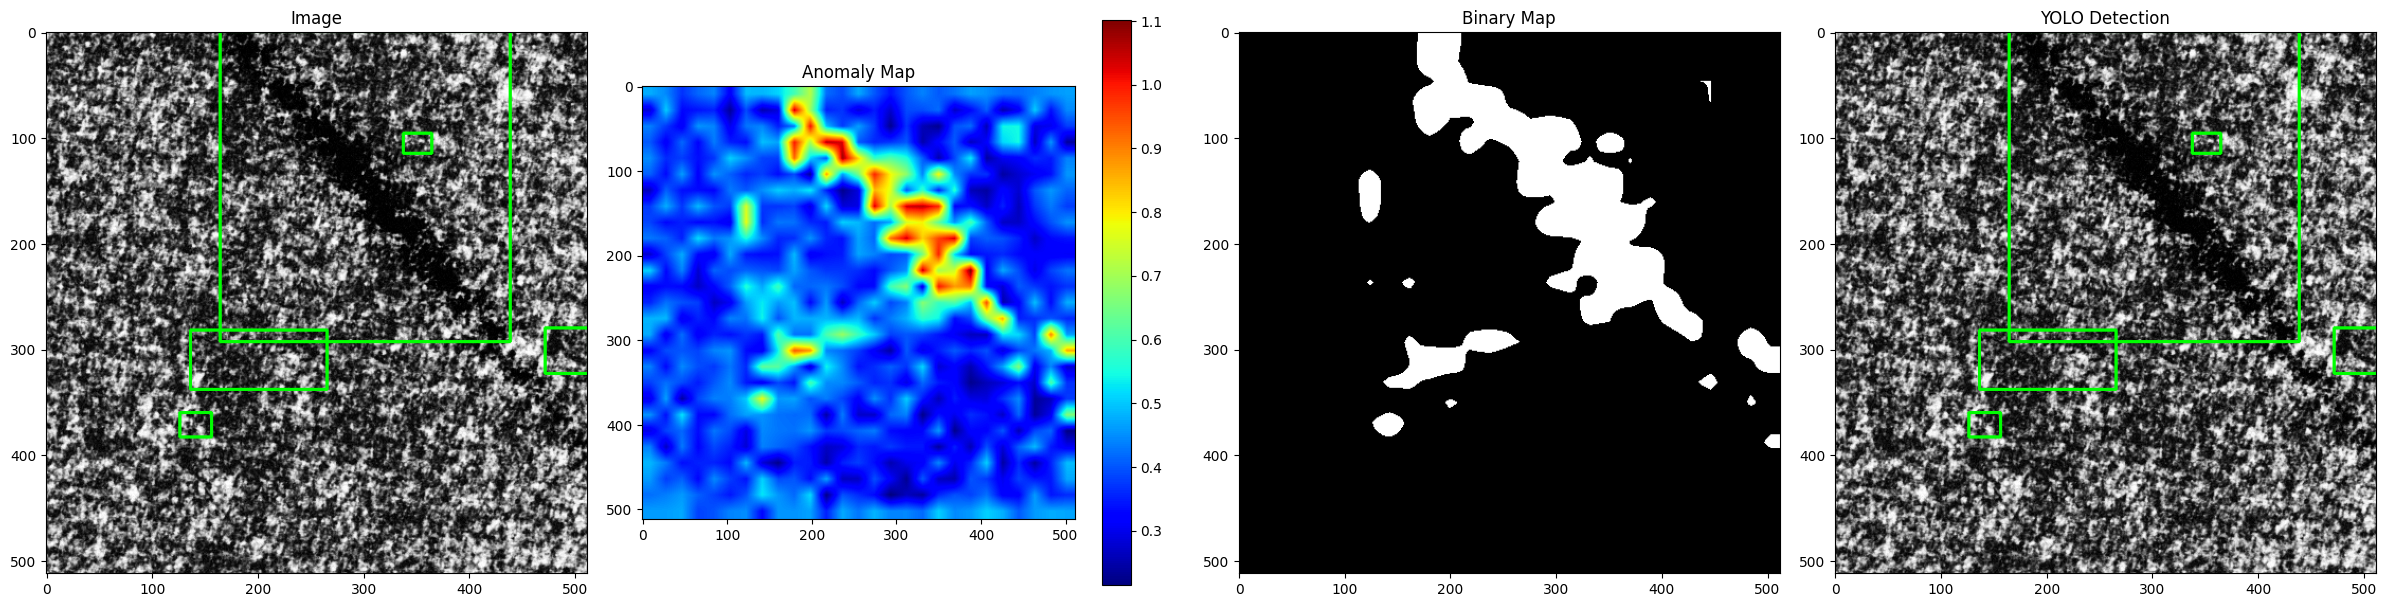

YOLO labels saved to /home/data/Datasets/public/tmp_features_huge/DAGM2007/Class6/Train/0618_anomaly.txt


In [61]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

def iou(box1, box2):
    """Calculate Intersection over Union (IoU) between two boxes."""
    # Convert YOLO boxes (x_center, y_center, width, height) to (x_min, y_min, x_max, y_max)
    x1_min = box1[1] - box1[3] / 2
    y1_min = box1[2] - box1[4] / 2
    x1_max = box1[1] + box1[3] / 2
    y1_max = box1[2] + box1[4] / 2

    x2_min = box2[1] - box2[3] / 2
    y2_min = box2[2] - box2[4] / 2
    x2_max = box2[1] + box2[3] / 2
    y2_max = box2[2] + box2[4] / 2

    # Calculate intersection
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)

    inter_area = max(0, inter_x_max - inter_x_min) * max(0, inter_y_max - inter_y_min)

    # Calculate union
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    union_area = box1_area + box2_area - inter_area

    # Return IoU
    return inter_area / union_area if union_area > 0 else 0


def non_max_suppression(yolo_boxes, iou_threshold=0.8):
    """Perform Non-Maximum Suppression (NMS) on YOLO boxes."""
    # Sort boxes by confidence score (descending)
    yolo_boxes = sorted(yolo_boxes, key=lambda x: x[0], reverse=True)

    nms_boxes = []
    while yolo_boxes:
        # Select the box with the highest confidence
        chosen_box = yolo_boxes.pop(0)
        nms_boxes.append(chosen_box)

        # Compare IoU with remaining boxes
        yolo_boxes = [
            box
            for box in yolo_boxes
            if iou(chosen_box, box) < iou_threshold
        ]

    return nms_boxes

def process_and_visualize_yolo(anomaly_map_path, image_path, yolo_output_path, threshold=0.5, top_k=5, class_id=0):
    """
    Process an anomaly map, resize it to match the image size, generate YOLO labels,
    and visualize anomaly map, binary map, and YOLO bounding boxes.

    Parameters:
        anomaly_map_path (str): Path to the .npy anomaly map file.
        image_path (str): Path to the corresponding image for resizing.
        yolo_output_path (str): Path to save YOLO format annotations.
        threshold (float): Threshold to binarize the anomaly map.
        min_area (int): Minimum size of connected regions to keep.
        class_id (int): Class ID for YOLO labels.
    """
    # Load the anomaly map
    anomaly_map = np.load(anomaly_map_path)
    print('anomaly_map max ', np.max(anomaly_map), ' -- ', np.min(anomaly_map))
    
    # Normalize the anomaly map to [0, 1] range
    #anomaly_map = (anomaly_map - np.min(anomaly_map)) / (np.max(anomaly_map) - np.min(anomaly_map))
    
    
    # Load the reference image to get the size
    image = cv2.imread(image_path)
    image_h, image_w = image.shape[:2]
    min_area = max((image_h//100)*(image_w//100), 10)
    
    # Resize the anomaly map to match the image size
    anomaly_map_resized = cv2.resize(anomaly_map, (image_w, image_h))
    print('anomaly_map_resized ', anomaly_map_resized.shape, ' -- ', min_area)
    
    # Binarize the anomaly map using the threshold
    binary_map = (anomaly_map_resized > threshold).astype(np.uint8) * 255  # Convert to 0 and 255

    # Find contours (connected components)
    contours, _ = cv2.findContours(binary_map, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Prepare YOLO labels
    yolo_labels = []
    binary_map_with_boxes = image  #cv2.cvtColor(binary_map, cv2.COLOR_GRAY2BGR)

    boxes = []
    for contour in contours:

        # Calculate the area of the contour
        area = cv2.contourArea(contour)
        if area < min_area:
            continue  # Skip small regions

        # Get bounding box
        x, y, w, h = cv2.boundingRect(contour)

        # Calculate region probability
        region = anomaly_map_resized[y:y+h, x:x+w]
        prob = np.max(region)

        # Convert to YOLO format
        x_center = (x + w / 2) / anomaly_map_resized.shape[1]
        y_center = (y + h / 2) / anomaly_map_resized.shape[0]
        width = w / anomaly_map_resized.shape[1]
        height = h / anomaly_map_resized.shape[0]

        # Append box
        boxes.append((prob, class_id, x_center, y_center, width, height))  # Class ID 0 for anomalies

    # Step 3: Sort boxes by probability and take top_k
    boxes = sorted(boxes, key=lambda x: x[0], reverse=True)[:top_k]

    # Step 4: Apply NMS
    nms_boxes = non_max_suppression(boxes, iou_threshold=0.8)
    print('nms_boxes ', len(nms_boxes))
    
    for box in nms_boxes:
        prob, class_id, x_center, y_center, width, height = box
        h, w = image.shape[:2]
        # Convert YOLO format to pixel coordinates
        x_min = int((x_center - width / 2) * w)
        y_min = int((y_center - height / 2) * h)
        x_max = int((x_center + width / 2) * w)
        y_max = int((y_center + height / 2) * h)
        
        # Draw rectangle
        cv2.rectangle(binary_map_with_boxes, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
    
    # Save YOLO labels to file
    with open(yolo_output_path, 'w') as f:
        for label in nms_boxes:
            f.write(f"{label[1]} {label[2]:.6f} {label[3]:.6f} {label[4]:.6f} {label[5]:.6f}\n")
    
    # Display the maps and results
    plt.figure(figsize=(24, 6))

    plt.subplot(1, 4, 1)
    plt.title("Image")
    plt.imshow(image)
    
    plt.subplot(1, 4, 2)
    plt.title("Anomaly Map")
    plt.imshow(anomaly_map_resized, cmap='jet')
    plt.colorbar()
    
    plt.subplot(1, 4, 3)
    plt.title("Binary Map")
    plt.imshow(binary_map, cmap='gray')
    
    plt.subplot(1, 4, 4)
    plt.title("YOLO Detection")
    plt.imshow(cv2.cvtColor(binary_map_with_boxes, cv2.COLOR_BGR2RGB))
    
    plt.tight_layout()
    plt.show()

    print(f"YOLO labels saved to {yolo_output_path}")

# Example usage (replace paths with actual files)
stats = {}
import random
cnt = 0

data_dir = '/home/data/Datasets/public/open_metal_datasets/'
data_file = data_dir+'metal_images_for_pretrain_v3_pretrain_mini_pretrain.txt'

with open(data_dir+'dataset_anomaly_max_mean.txt', 'r') as r_data:
    for line in r_data:
        data = line.strip()
        cls1 = data.split('  --  ')[0].strip()
        cls2 = data.split('  --  ')[1].split('  -->  ')[0].strip()
        max_mean = float(data.split('  --  ')[1].split('  -->  ')[1].split('  // max  ')[0].strip())
        if cls1 not in stats:
            stats[cls1] = {}
        stats[cls1][cls2] = max_mean

#for cls1 in stats:
#    for cls2 in stats[cls1]:
#        print(cls1, ' -- ', cls2, ' --> ', np.mean(stats[cls1][cls2]), ' // max ', np.max(stats[cls1][cls2]))

with open(data_file, 'r') as r_data:
    for line in r_data:
        data = line.strip().split(' ')
        #if random.random() < 0.5 or 'APDDD' in data[0]:
        #    continue
        if len(data) < 3:
            continue
        image_path = data[0].strip()
        anomaly_map_path = data[2].strip()
        if not os.path.exists(image_path) or not os.path.join(anomaly_map_path):
            print('not exists! ', line)
            continue
        cnt += 1
        if cnt != 16570:
            continue
        output_path = anomaly_map_path.replace('.npy', '.txt')
        cls1 = image_path.split('/')[5]
        
        cls2 = image_path.split('/')[6]
        '''
        if cls1 not in stats:
            stats[cls1] = {}
        if cls2 not in stats[cls1]:
            stats[cls1][cls2] = []
        anomaly_map = np.load(anomaly_map_path)
        stats[cls1][cls2].append(np.max(anomaly_map))
        '''

        max_mean = stats[cls1][cls2]
        
        process_and_visualize_yolo(
            anomaly_map_path=anomaly_map_path,
            image_path=image_path,
            yolo_output_path=output_path,
            threshold=(max_mean-0.1),
            top_k=10,
            class_id=0
        )
        break
        
        #if cnt > 1000:
        #    break

